# CE 310 — Week 13 Lab: Monte Carlo Simulation
**Course:** Probability & Statistics for Civil/Architectural Engineering  
**University of Arizona**

---

## Learning Objectives

By the end of this lab you will be able to:

1. Implement a Monte Carlo simulation in Python using `numpy` to propagate input uncertainty through a predictive model.
2. Compare simulated uncertainty to an analytical calculation and explain any difference.
3. Extract percentiles and exceedance probabilities from a simulated distribution to support budget decisions.
4. Decompose output variance into contributions from individual uncertain inputs (OAT-MC method).
5. Interpret variance decomposition results in the context of the Week 12 tornado diagram.

---

## Scenario: Annual Energy Cost Uncertainty for the DOE Medium Office

In Weeks 10–12 you fit two regression models for hourly cooling energy and performed one-at-a-time (OAT) sensitivity analysis. The key Week 12 findings were:

- A **±5°F temperature bias** propagates to **±44,936 kWh/yr** (27% of annual total)
- A **±260 occupied-hour shift** propagates to **±4,642 kWh/yr** (2.8% of annual total)
- Temperature sensitivity is **9.7× greater** than occupancy sensitivity

Those were *deterministic* OAT swings — what happens if inputs are *random* and *simultaneously* uncertain?

In this lab, you will model three sources of **annual uncertainty** using Normal distributions:

| Uncertain Input | Distribution | Physical Meaning |
|---|---|---|
| `delta_T` — year-to-year temperature anomaly | Normal(0, 2°F) | Climate variability |
| `delta_occ` — annual occupied-hour deviation | Normal(0, 100 hrs) | Schedule uncertainty |
| `rate` — electricity rate (\$/kWh) | Normal(0.12, 0.01) | Market price uncertainty |

**Annual model (hardcoded from Week 10 Model 2):**

```
annual_kWh  = BASE_KWH + delta_T × N_HOURS × SLOPE + delta_occ × BH_COEF
annual_cost = annual_kWh × rate
```

All regression parameters are **hardcoded** — no CSV file is needed for this lab.

---

### Grading Summary

| Section | Questions | Points | Type |
|---|---|---|---|
| A | A1–A8 | 16 pts | Numeric answers |
| B | B2–B10 | 32 pts | Numeric answers |
| B manual | B1, B_written, Reflection, Memo | 20 pts | Instructor-graded |
| **Total** | | **68 pts** | |

**Answer format:** Every numeric answer must follow this exact pattern:
```python
ANSWER_XX = round(expr, dp)
print(f"ANSWER_XX = {ANSWER_XX}")
```
The `print` output is what gets read — missing prints = 0 pts.

## Before You Begin

**No data file upload needed.** This lab uses Monte Carlo simulation — all values are generated by the code itself using the regression model from Week 10. There is no CSV to upload.

> **In Colab:** Runtime → Run all to execute all cells in order. If you edit any parameter cell, re-run from that cell downward.


*NumPy RNG API note (ungraded): This lab uses the legacy API: `np.random.seed(42)` followed by `np.random.normal(...)`. The Week 14 lab and assignment use the newer API: `rng = np.random.default_rng(SEED)` followed by `rng.normal(...)`. Both produce the same distributions — the difference is in reproducibility and thread safety. The newer API (`np.random.default_rng`) is preferred for new code because each `rng` instance is independent, making parallel and multi-threaded Monte Carlo safer. The seeded results will differ between the two APIs (same seed ≠ same draws), which is why this lab and the assignment use different seed values.*


## Setup

Run the two cells below before starting. They import libraries and define all model parameters.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

In [ ]:
# ── Model 2 parameters (Week 10 regression, hardcoded) ─────────────────────────
# Cooling_kWh ~ Outdoor_Temp_F + BH
# R² = 0.6972
BASE_KWH  = 166_107   # kWh/yr  — annual base prediction at mean T and BH hours
SLOPE     = 1.0259    # kWh/°F·hr  — Outdoor_Temp_F coefficient
BH_COEF   = 17.853    # kWh/hr  — Business Hours (occupied) coefficient

# ── Calendar constants ─────────────────────────────────────────────────────────
N_HOURS   = 8_760     # hours/yr  (= 365 × 24)

# ── Electricity rate baseline ──────────────────────────────────────────────────
RATE_BASE = 0.12      # $/kWh

# ── Monte Carlo settings ───────────────────────────────────────────────────────
N = 10_000            # number of simulation draws

print("Parameters set:")
print(f"  BASE_KWH  = {BASE_KWH:,} kWh/yr")
print(f"  SLOPE     = {SLOPE} kWh/°F·hr")
print(f"  BH_COEF   = {BH_COEF} kWh/hr")
print(f"  N_HOURS   = {N_HOURS:,} hr/yr")
print(f"  RATE_BASE = ${RATE_BASE}/kWh")
print(f"  N         = {N:,} Monte Carlo draws")

---
## Section A — Single-Input MC and Full 3-Input MC (16 pts)

We start simple: only one input is uncertain at a time. This lets you verify your code against an
analytical result before moving to the full simulation.

### Background: How Monte Carlo Propagates Uncertainty

Monte Carlo simulation replaces each uncertain input with a **random draw** from its probability distribution.
Running N = 10,000 draws produces 10,000 plausible annual outcomes. The empirical distribution of those
outcomes characterises the output uncertainty.

For a linear model Y = a + b·X where X ~ Normal(μ, σ):
- E[Y] = a + b·μ  (linearity of expectation)
- Var(Y) = b²·Var(X)  →  **σ_Y = |b| · σ_X**  (analytical result)

In Section A you will first confirm this analytically for the temperature input, then run the
full 3-input simulation.

### A1 — Mean Annual kWh (Temperature-Only MC) *(2 pts)*

Draw `delta_T` from Normal(0, 2°F) with **seed = 42** and N = 10,000 samples.
Compute `kWh_single_T = BASE_KWH + delta_T * N_HOURS * SLOPE`.

Assign **`ANSWER_A1_kWh_mean_single_T`** = the mean of `kWh_single_T`, rounded to the **nearest integer** (0 decimal places).

In [ ]:
# Draw N samples of the temperature anomaly
np.random.seed(42)
delta_T = np.random.normal(0, 2, N)    # Normal(mean=0, std=2°F), N draws

# Compute annual kWh with only temperature varying
# (delta_occ = 0, rate = RATE_BASE — not used here)
kWh_single_T = BASE_KWH + delta_T * N_HOURS * SLOPE

# Mean: should be close to BASE_KWH because E[delta_T] = 0
ANSWER_A1_kWh_mean_single_T = round(kWh_single_T.mean(), 0)
print(f"ANSWER_A1_kWh_mean_single_T = {ANSWER_A1_kWh_mean_single_T}")

### A2 — Standard Deviation of Annual kWh (Temperature-Only MC) *(2 pts)*

Using the same `kWh_single_T` array from A1, compute the **standard deviation**.

Assign **`ANSWER_A2_kWh_std_single_T`** = `kWh_single_T.std()`, rounded to the **nearest integer**.

In [ ]:
# Standard deviation of the simulated annual kWh distribution
ANSWER_A2_kWh_std_single_T = round(kWh_single_T.std(), 0)
print(f"ANSWER_A2_kWh_std_single_T = {ANSWER_A2_kWh_std_single_T}")
print(f"  → Simulated σ_kWh ≈ {ANSWER_A2_kWh_std_single_T:,.0f} kWh/yr")

### A3 — Analytical Standard Deviation Check *(2 pts)*

For a linear model  `annual_kWh = BASE_KWH + delta_T × N_HOURS × SLOPE`  
with  `delta_T ~ Normal(0, σ_T)`:  

$$\sigma_{\text{kWh,T}} = \sigma_T \times N_{\text{hours}} \times \text{SLOPE}$$

Compute the **analytical** standard deviation using σ_T = 2°F.

Assign **`ANSWER_A3_analytical_kWh_std_T`** = the analytical value, rounded to the **nearest integer**.

*Compare to A2 — they should be within a few hundred kWh (sampling noise at N = 10,000).*

In [ ]:
# Analytical derivation:
# Var(b*X) = b² * Var(X)  →  σ_Y = |b| * σ_X
# Here b = N_HOURS * SLOPE, X = delta_T with σ_X = 2°F
sigma_T = 2.0    # °F — standard deviation of the temperature anomaly distribution

sigma_kWh_T = sigma_T * N_HOURS * SLOPE

ANSWER_A3_analytical_kWh_std_T = round(sigma_kWh_T, 0)
print(f"ANSWER_A3_analytical_kWh_std_T = {ANSWER_A3_analytical_kWh_std_T}")
print(f"  Analytical: σ_T × N_HOURS × SLOPE = {sigma_T} × {N_HOURS} × {SLOPE} = {sigma_kWh_T:,.1f} kWh/yr")
print(f"  Simulated  (A2): {ANSWER_A2_kWh_std_single_T:,.0f} kWh/yr")
print(f"  Difference: {abs(ANSWER_A2_kWh_std_single_T - ANSWER_A3_analytical_kWh_std_T):,.0f} kWh/yr (sampling noise)")


*Analytical z-score check (ungraded): You can verify the MC distribution analytically. For `kWh_single_T ~ Normal(BASE_KWH, σ_kWh_T)`, the probability of exceeding BASE_KWH + σ_kWh_T should be about 15.9% (one standard deviation above the mean). Check: `(kWh_single_T > BASE_KWH + sigma_kWh_T).mean()` should be ≈ 0.159. Similarly, the fraction below BASE_KWH − σ_kWh_T should also be ≈ 0.159. If these match, your MC is sampling from the right distribution. This type of analytical spot-check is good practice whenever you build a new simulation.*


---
### Full 3-Input Monte Carlo Setup

Now we add all three uncertain inputs simultaneously:
- `delta_T  ~ Normal(0, 2)` °F
- `delta_occ ~ Normal(0, 100)` hrs
- `rate ~ Normal(0.12, 0.01)` \$/kWh

The three inputs are **independent** — each draw is generated from its own distribution.  
All three are drawn with **seed = 42** (call `np.random.seed(42)` once before all three draws).

**Important:** Re-seed once before this block. Do not re-seed between individual draws.

In [ ]:
# ── Full 3-Input Monte Carlo ────────────────────────────────────────────────────
# Seed once; then draw all three inputs in sequence
np.random.seed(42)
delta_T   = np.random.normal(0,    2,    N)    # temperature anomaly (°F)
delta_occ = np.random.normal(0,    100,  N)    # occupied-hour deviation (hrs/yr)
rate      = np.random.normal(0.12, 0.01, N)    # electricity rate ($/kWh)

# Annual cooling energy for each of the N scenarios
annual_kWh  = BASE_KWH + delta_T * N_HOURS * SLOPE + delta_occ * BH_COEF

# Annual cost for each scenario
annual_cost = annual_kWh * rate

print(f"Full MC setup complete: {N:,} annual scenarios generated.")
print(f"  annual_kWh  range: [{annual_kWh.min():,.0f}, {annual_kWh.max():,.0f}] kWh/yr")
print(f"  annual_cost range: [${annual_cost.min():,.0f}, ${annual_cost.max():,.0f}]")

### A4 — Mean Annual Cost (Full MC) *(2 pts)*

Using the `annual_cost` array from the full 3-input MC above, compute the **mean** annual cost.

Assign **`ANSWER_A4_cost_mean_full`** = `annual_cost.mean()`, rounded to **1 decimal place**.

In [ ]:
# Mean of the simulated annual cost distribution
ANSWER_A4_cost_mean_full = round(annual_cost.mean(), 1)
print(f"ANSWER_A4_cost_mean_full = {ANSWER_A4_cost_mean_full}")
print(f"  Mean annual cost ≈ ${ANSWER_A4_cost_mean_full:,.1f}")
print(f"  Check: BASE_KWH × RATE_BASE = {BASE_KWH:,} × {RATE_BASE} = ${BASE_KWH*RATE_BASE:,.1f}")

### A5 — Standard Deviation of Annual Cost (Full MC) *(2 pts)*

Assign **`ANSWER_A5_cost_std_full`** = `annual_cost.std()`, rounded to **1 decimal place**.

*This captures the combined effect of all three uncertain inputs on cost.*

In [ ]:
# Standard deviation — the "typical" annual cost deviation from the mean
ANSWER_A5_cost_std_full = round(annual_cost.std(), 1)
print(f"ANSWER_A5_cost_std_full = {ANSWER_A5_cost_std_full}")
print(f"  Cost std ≈ ${ANSWER_A5_cost_std_full:,.1f}")
print(f"  As % of mean: {ANSWER_A5_cost_std_full / ANSWER_A4_cost_mean_full * 100:.1f}%")

### A6 — 5th Percentile of Annual Cost *(2 pts)*

The **5th percentile** is the cost value below which 5% of simulated years fall.  
It represents a low-cost scenario (favorable year).

Assign **`ANSWER_A6_cost_p05`** = `np.percentile(annual_cost, 5)`, rounded to **1 decimal place**.

In [ ]:
# 5th percentile — lower tail of the cost distribution
ANSWER_A6_cost_p05 = round(np.percentile(annual_cost, 5), 1)
print(f"ANSWER_A6_cost_p05 = {ANSWER_A6_cost_p05}")

### A7 — 95th Percentile of Annual Cost *(2 pts)*

The **95th percentile** is the cost value below which 95% of simulated years fall.  
Setting a budget at P95 gives 95% confidence of staying on budget.

Assign **`ANSWER_A7_cost_p95`** = `np.percentile(annual_cost, 95)`, rounded to **1 decimal place**.

In [ ]:
# 95th percentile — upper tail of the cost distribution
ANSWER_A7_cost_p95 = round(np.percentile(annual_cost, 95), 1)
print(f"ANSWER_A7_cost_p95 = {ANSWER_A7_cost_p95}")
print(f"  90% CI (P5 to P95): ${ANSWER_A6_cost_p05:,.1f} to ${ANSWER_A7_cost_p95:,.1f}")
print(f"  90% CI width: ${ANSWER_A7_cost_p95 - ANSWER_A6_cost_p05:,.1f}")

**Target shape for the cost histogram:**

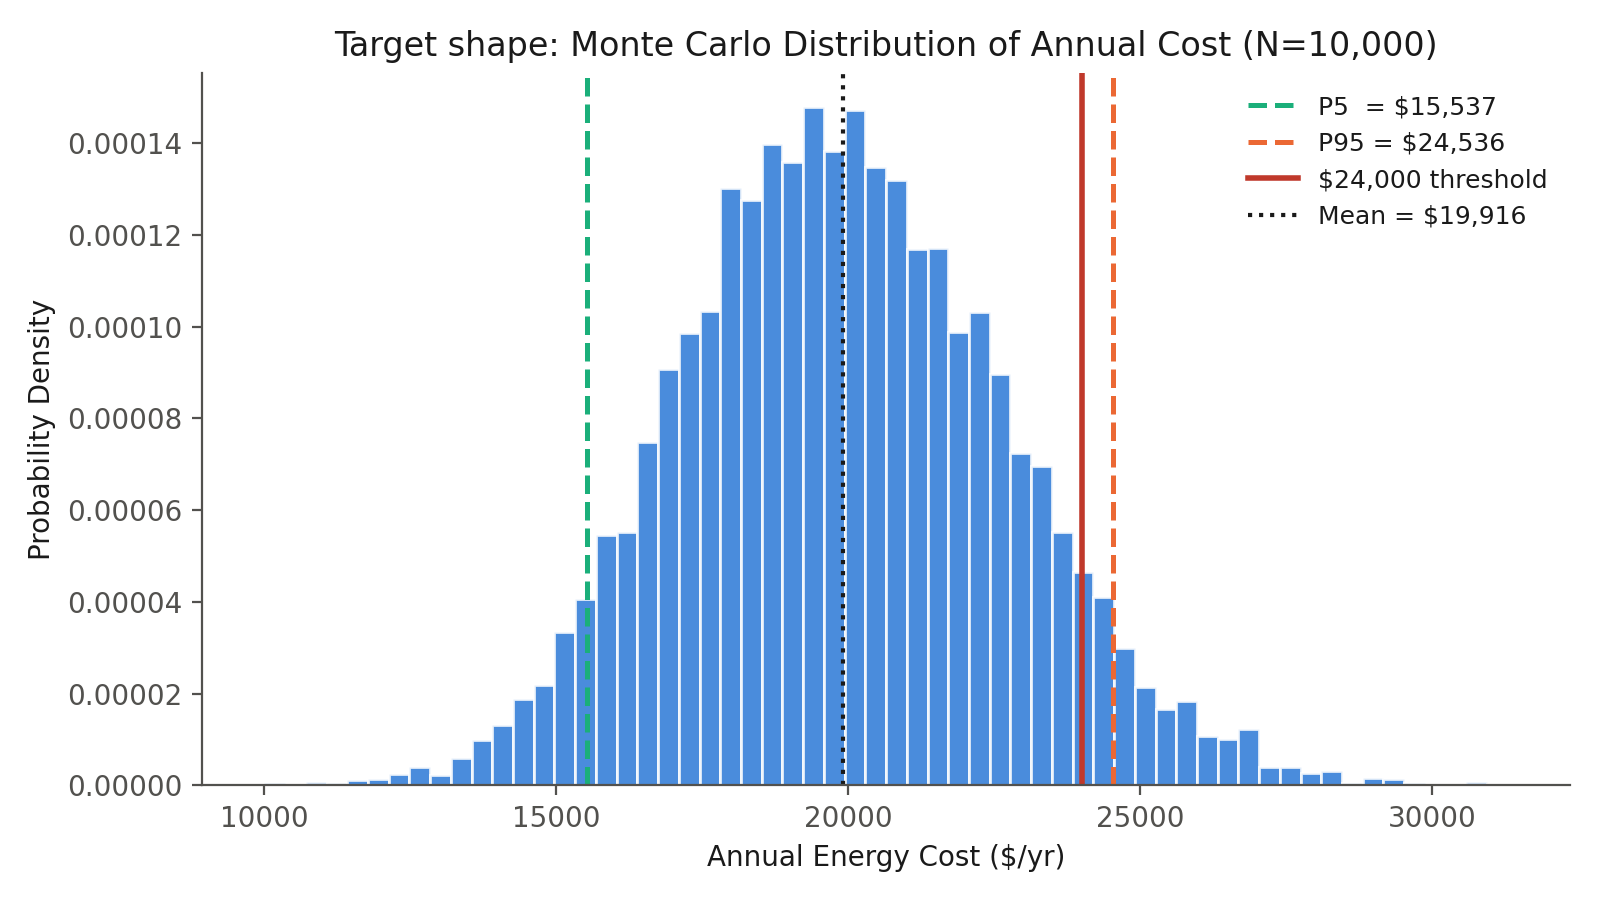


In [ ]:
# ── Histogram of annual cost distribution ──────────────────────────────────────
# (No ANSWER_ variable — visualization only)
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(annual_cost, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)

# Mark key percentiles
ax.axvline(ANSWER_A6_cost_p05, color='green',  linestyle='--', linewidth=1.8, label=f'P5  = ${ANSWER_A6_cost_p05:,.0f}')
ax.axvline(ANSWER_A7_cost_p95, color='orange', linestyle='--', linewidth=1.8, label=f'P95 = ${ANSWER_A7_cost_p95:,.0f}')
ax.axvline(24_000,             color='red',    linestyle='-',  linewidth=2.0, label='$24,000 threshold')
ax.axvline(ANSWER_A4_cost_mean_full, color='black', linestyle=':', linewidth=1.5, label=f'Mean = ${ANSWER_A4_cost_mean_full:,.0f}')

ax.set_xlabel('Annual Energy Cost ($/yr)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Monte Carlo Distribution of Annual Energy Cost\n(N = 10,000 simulated years, 3 uncertain inputs)', fontsize=13)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### A8 — Probability of Exceeding \$24,000 *(2 pts)*

Compute the fraction of simulated years in which annual cost exceeds \$24,000.

Assign **`ANSWER_A8_prob_over_24k`** = `(annual_cost > 24_000).mean()`, rounded to **4 decimal places**.

In [ ]:
# Exceedance probability: fraction of N scenarios where cost > $24,000
# (annual_cost > 24_000) is a boolean array; .mean() gives the fraction True
ANSWER_A8_prob_over_24k = round((annual_cost > 24_000).mean(), 4)
print(f"ANSWER_A8_prob_over_24k = {ANSWER_A8_prob_over_24k}")
print(f"  ~{ANSWER_A8_prob_over_24k*100:.1f}% of years expected to exceed $24,000")

---
## Section B — Variance Decomposition and Advanced Analysis (32 pts auto + 20 pts manual)

Section B addresses: *Which uncertain input drives cost uncertainty the most?*

We use an **OAT-MC (one-at-a-time Monte Carlo)** approach to attribute total cost variance
to individual inputs.

### B1 — Variance Decomposition Method *(4 pts — manually graded)*

**Written question — answer in the markdown cell below.**

The OAT-MC variance decomposition works as follows:

> To isolate the variance contribution of input X_i, draw X_i from its distribution while holding
> all other inputs at their mean values. The variance of the output in this restricted simulation
> equals the variance attributable to X_i alone.

**In 3–4 sentences, explain:**
1. Why does holding the other inputs at their means isolate X_i's contribution?
2. Under what condition is it valid to add up the individual variance contributions to get total variance?
3. What would happen to the decomposition if two inputs were positively correlated (e.g., hot years tend to also have higher electricity rates)?

*Write your answer in the cell directly below.*

**B1 Answer (replace this text with your explanation):**

*(Write 3–4 sentences here.)*

### B2–B4 — Variance Decomposition: % of Total Cost Variance by Input *(4 + 4 + 4 = 12 pts)*

For each of the three uncertain inputs, run a **separate** Monte Carlo where only that input varies
and the other two are held at their mean values:

| Run | `delta_T` | `delta_occ` | `rate` |
|---|---|---|---|
| T-only  | Normal(0, 2) | **0** | **RATE_BASE** |
| occ-only | **0** | Normal(0, 100) | **RATE_BASE** |
| rate-only | **0** | **0** | Normal(0.12, 0.01) |

Compute the **variance** of `annual_cost` in each run, sum them for `var_total`, then express
each as a **percentage** of `var_total`.

**Use `np.random.seed(42)` before each separate draw.**

Assign:
- **`ANSWER_B2_var_T_pct`** — % from temperature, rounded to **1 decimal place**
- **`ANSWER_B3_var_occ_pct`** — % from occupancy, rounded to **2 decimal places**
- **`ANSWER_B4_var_rate_pct`** — % from electricity rate, rounded to **1 decimal place**

In [ ]:
# ── OAT-MC Variance Decomposition ──────────────────────────────────────────────
# Run 1: temperature only (delta_occ = 0, rate = RATE_BASE)
np.random.seed(42)
delta_T_oat   = np.random.normal(0, 2, N)
kWh_T_oat     = BASE_KWH + delta_T_oat * N_HOURS * SLOPE    # occ term = 0
cost_T_oat    = kWh_T_oat * RATE_BASE                        # rate fixed at mean
var_T         = cost_T_oat.var()

# Run 2: occupancy only (delta_T = 0, rate = RATE_BASE)
np.random.seed(42)
delta_occ_oat = np.random.normal(0, 100, N)
kWh_occ_oat   = BASE_KWH + delta_occ_oat * BH_COEF           # T term = 0
cost_occ_oat  = kWh_occ_oat * RATE_BASE                      # rate fixed at mean
var_occ       = cost_occ_oat.var()

# Run 3: electricity rate only (delta_T = 0, delta_occ = 0)
np.random.seed(42)
rate_oat      = np.random.normal(0.12, 0.01, N)
cost_rate_oat = BASE_KWH * rate_oat                           # kWh = BASE_KWH (no deviation)
var_rate      = cost_rate_oat.var()

# Total variance (additive because inputs are independent)
var_total = var_T + var_occ + var_rate

# Express each as a percentage of total
ANSWER_B2_var_T_pct   = round(var_T   / var_total * 100, 1)
ANSWER_B3_var_occ_pct = round(var_occ / var_total * 100, 2)
ANSWER_B4_var_rate_pct = round(var_rate / var_total * 100, 1)

print(f"ANSWER_B2_var_T_pct = {ANSWER_B2_var_T_pct}")
print(f"ANSWER_B3_var_occ_pct = {ANSWER_B3_var_occ_pct}")
print(f"ANSWER_B4_var_rate_pct = {ANSWER_B4_var_rate_pct}")
print()
print("Variance decomposition summary:")
print(f"  Temperature  : {ANSWER_B2_var_T_pct:5.1f}%  (σ = ${np.sqrt(var_T):,.0f}/yr)")
print(f"  Occupancy    : {ANSWER_B3_var_occ_pct:5.2f}%  (σ = ${np.sqrt(var_occ):,.0f}/yr)")
print(f"  Elec. rate   : {ANSWER_B4_var_rate_pct:5.1f}%  (σ = ${np.sqrt(var_rate):,.0f}/yr)")
print(f"  Total        : {ANSWER_B2_var_T_pct + ANSWER_B3_var_occ_pct + ANSWER_B4_var_rate_pct:.1f}%")

The bar chart below visualises the variance decomposition as a percentage stacked bar — a
"variance tornado" analogous to the Week 12 tornado diagram.

**Target shape for the variance decomposition bar chart:**

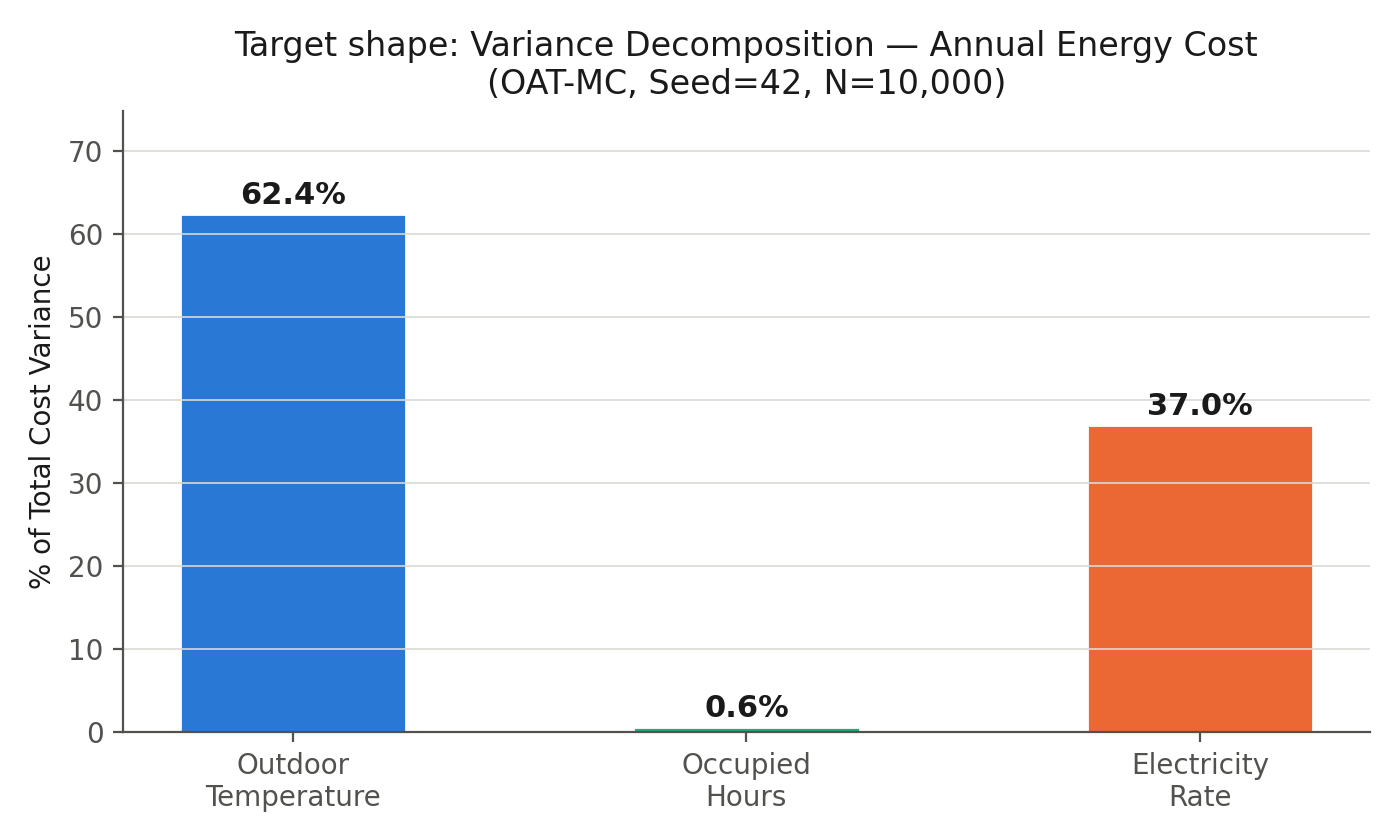


In [ ]:
# ── Variance decomposition bar chart ───────────────────────────────────────────
# (No ANSWER_ variable — visualization only)
labels  = ['Outdoor\nTemperature', 'Occupied\nHours', 'Electricity\nRate']
pcts    = [ANSWER_B2_var_T_pct, ANSWER_B3_var_occ_pct, ANSWER_B4_var_rate_pct]
colors  = ['#d73027', '#fee090', '#4575b4']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, pcts, color=colors, edgecolor='white', width=0.5)

# Label each bar with its percentage
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('% of Total Cost Variance', fontsize=12)
ax.set_title('Variance Decomposition — Annual Energy Cost\n(OAT-MC Method, Seed=42, N=10,000)', fontsize=12)
ax.set_ylim(0, max(pcts) * 1.15)
plt.tight_layout()
plt.show()
print("Note: Electricity rate was NOT in the Week 12 tornado (it is external to the regression).")

### B5–B7 — 80% Confidence Interval *(3 + 3 + 4 = 10 pts)*

Using the full `annual_cost` array (from the 3-input MC setup cell), compute:

- **`ANSWER_B5_cost_p10`** — 10th percentile, rounded to **1 decimal place**
- **`ANSWER_B6_cost_p90`** — 90th percentile, rounded to **1 decimal place**
- **`ANSWER_B7_cost_range_p80`** — P90 − P10 (the 80% CI width), rounded to **1 decimal place**

*The 80% CI tells a budget planner: "The middle 80% of plausible annual costs falls within this range."*

In [ ]:
# 10th and 90th percentiles of the full Monte Carlo cost distribution
ANSWER_B5_cost_p10 = round(np.percentile(annual_cost, 10), 1)
ANSWER_B6_cost_p90 = round(np.percentile(annual_cost, 90), 1)

# 80% CI width: P90 - P10
ANSWER_B7_cost_range_p80 = round(ANSWER_B6_cost_p90 - ANSWER_B5_cost_p10, 1)

print(f"ANSWER_B5_cost_p10 = {ANSWER_B5_cost_p10}")
print(f"ANSWER_B6_cost_p90 = {ANSWER_B6_cost_p90}")
print(f"ANSWER_B7_cost_range_p80 = {ANSWER_B7_cost_range_p80}")
print()
print(f"  80% CI: ${ANSWER_B5_cost_p10:,.1f} to ${ANSWER_B6_cost_p90:,.1f}")
print(f"  Width : ${ANSWER_B7_cost_range_p80:,.1f} ({ANSWER_B7_cost_range_p80/ANSWER_A4_cost_mean_full*100:.1f}% of mean)")

### B8 — Probability of Exceeding \$25,000 *(4 pts)*

Assign **`ANSWER_B8_prob_over_25k`** = `(annual_cost > 25_000).mean()`, rounded to **4 decimal places**.

*Compare to A8 (P > \$24k). How does a \$1,000 higher threshold change the exceedance probability?*

In [ ]:
# Exceedance probability at $25,000 threshold
ANSWER_B8_prob_over_25k = round((annual_cost > 25_000).mean(), 4)
print(f"ANSWER_B8_prob_over_25k = {ANSWER_B8_prob_over_25k}")
print()
print(f"  P(cost > $24,000) = {ANSWER_A8_prob_over_24k}  ({ANSWER_A8_prob_over_24k*100:.2f}%)")
print(f"  P(cost > $25,000) = {ANSWER_B8_prob_over_25k}  ({ANSWER_B8_prob_over_25k*100:.2f}%)")
print(f"  A $1,000 higher budget threshold roughly halved the exceedance probability.")

### B9 — Rate Threshold: What Rate Keeps P(cost > \$24k) Below 5%? *(4 pts)*

Your client wants P(annual_cost > \$24,000) < 5%. This could be achieved by negotiating a
fixed electricity contract at a lower mean rate.

Search for the **highest** `rate_mean` (in steps of \$0.001/kWh, decreasing from 0.120)
at which the exceedance probability first drops below 5%.

**Pattern:**
```python
for rate_mean in np.arange(0.120, 0.100, -0.001):
    np.random.seed(42)
    # draw delta_T_, delta_occ_, rate_ (same sigma; only rate_mean changes)
    # compute kWh_, cost_
    if (cost_ > 24_000).mean() < 0.05:
        ANSWER_B9_rate_for_p5_under_24k = round(rate_mean, 3)
        break
```

Assign **`ANSWER_B9_rate_for_p5_under_24k`** rounded to **3 decimal places**.

In [ ]:
# Search for the highest rate_mean where P(cost > $24k) < 5%
ANSWER_B9_rate_for_p5_under_24k = None   # will be set when the condition is met

for rate_mean in np.arange(0.120, 0.100, -0.001):
    np.random.seed(42)
    delta_T_   = np.random.normal(0,         2,    N)
    delta_occ_ = np.random.normal(0,         100,  N)
    rate_      = np.random.normal(rate_mean, 0.01, N)   # sigma stays 0.01; only mean changes
    kWh_  = BASE_KWH + delta_T_ * N_HOURS * SLOPE + delta_occ_ * BH_COEF
    cost_ = kWh_ * rate_
    prob_ = (cost_ > 24_000).mean()
    if prob_ < 0.05:
        ANSWER_B9_rate_for_p5_under_24k = round(rate_mean, 3)
        print(f"  rate_mean = {rate_mean:.3f}  →  P(cost > $24k) = {prob_:.4f} < 5% ✓")
        break
    else:
        print(f"  rate_mean = {rate_mean:.3f}  →  P(cost > $24k) = {prob_:.4f}  (still ≥ 5%)")

print()
print(f"ANSWER_B9_rate_for_p5_under_24k = {ANSWER_B9_rate_for_p5_under_24k}")
print(f"  Reduction from baseline: {0.120 - ANSWER_B9_rate_for_p5_under_24k:.3f} $/kWh")
print(f"  ({(0.120 - ANSWER_B9_rate_for_p5_under_24k)/0.120*100:.1f}% reduction in mean rate)")

### B10 — Model 5 Comparison: Does Model Choice Affect Cost Uncertainty? *(2 pts)*

In Week 12 you saw that Model 5 (interaction model) has slightly different annual sensitivity than
Model 2. Here, replace Model 2's temperature sensitivity (`N_HOURS × SLOPE = 8,760 × 1.0259`)
with Model 5's **annual sensitivity** computed from the occupied/unoccupied slopes:

```
kWh_sens_m5 = N_OCC × OCC_SLOPE + N_UNOCC × UNOCC_SLOPE
```

where: N_OCC = 2,600 hrs/yr, N_UNOCC = 6,160 hrs/yr, OCC_SLOPE = 1.7813, UNOCC_SLOPE = 0.7127.

Draw fresh samples with **seed = 42**, compute `kWh_m5` and `cost_m5`, then assign
**`ANSWER_B10_m5_cost_std`** = `cost_m5.std()` rounded to **1 decimal place**.

*Compare to A5. Are the two models effectively equivalent for annual cost budgeting?*

In [ ]:
# Model 5 parameters (from Week 12)
N_OCC      = 2_600   # occupied hours/yr
N_UNOCC    = 6_160   # unoccupied hours/yr  (N_OCC + N_UNOCC = 8,760)
OCC_SLOPE  = 1.7813  # kWh/°F  (occupied building)
UNOCC_SLOPE = 0.7127 # kWh/°F  (unoccupied building)

# Annual sensitivity: total kWh change per 1°F shift across all hours
kWh_sens_m5 = N_OCC * OCC_SLOPE + N_UNOCC * UNOCC_SLOPE
print(f"Model 5 annual sensitivity: {N_OCC}×{OCC_SLOPE} + {N_UNOCC}×{UNOCC_SLOPE} = {kWh_sens_m5:,.1f} kWh/°F")
print(f"Model 2 annual sensitivity: {N_HOURS}×{SLOPE} = {N_HOURS*SLOPE:,.1f} kWh/°F")
print()

# Full Monte Carlo using Model 5 sensitivity
np.random.seed(42)
delta_T_m5   = np.random.normal(0,    2,    N)
delta_occ_m5 = np.random.normal(0,    100,  N)
rate_m5      = np.random.normal(0.12, 0.01, N)

kWh_m5  = BASE_KWH + delta_T_m5 * kWh_sens_m5 + delta_occ_m5 * BH_COEF
cost_m5 = kWh_m5 * rate_m5

ANSWER_B10_m5_cost_std = round(cost_m5.std(), 1)
print(f"ANSWER_B10_m5_cost_std = {ANSWER_B10_m5_cost_std}")
print()
print(f"  Model 2 cost std (A5): ${ANSWER_A5_cost_std_full:,.1f}/yr")
print(f"  Model 5 cost std (B10): ${ANSWER_B10_m5_cost_std:,.1f}/yr")
print(f"  Difference: ${abs(ANSWER_B10_m5_cost_std - ANSWER_A5_cost_std_full):.1f}/yr")
print("  → Model choice makes essentially no difference for annual cost uncertainty budgeting.")

---
### B — Written Response: Rate vs. Tornado *(4 pts — manually graded)*

**In 2–3 sentences, explain:**

> Why does electricity rate appear as a large uncertainty source (36.4%) in the Monte Carlo
> variance decomposition, but did **not** appear in the Week 12 tornado diagram?
> What does this tell you about the difference between regression parameter sensitivity
> and total cost uncertainty?

*Write your answer in the cell below.*

**B Written Answer (replace this text):**

*(Write 2–3 sentences here.)*

---
### Technical Memo *(8 pts — manually graded)*

Write a **3-paragraph technical memo** addressed to the building's facilities manager.
Use the quantitative results from this lab. Target length: 150–250 words.

**Paragraph 1 — Annual Cost Distribution:**  
Report the mean, standard deviation, 80% CI (P10–P90), and the P95 budget target.
Express the 80% CI width as a percentage of the mean cost.

**Paragraph 2 — Variance Decomposition and Connection to Week 12:**  
State the three variance percentages (T, occ, rate). Explain why electricity rate appears
as the second-largest driver even though it was not in the Week 12 tornado diagram.
Note the Model 5 vs. Model 2 cost-std finding from B10.

**Paragraph 3 — Engineering Recommendation:**  
Recommend a specific, actionable risk management strategy. Justify it with at least one
number from the lab (e.g., rate threshold from B9, variance percentage, budget level).

*Write your memo in the cell below.*

**MEMO**

**TO:** Facilities Manager  
**FROM:** [Your Name]  
**DATE:** [Date]  
**RE:** Annual Energy Cost Uncertainty — DOE Medium Office

---

*Paragraph 1 — Cost Distribution:*  
*(Replace this text.)*

*Paragraph 2 — Variance Decomposition:*  
*(Replace this text.)*

*Paragraph 3 — Recommendation:*  
*(Replace this text.)*

---
### Reflection *(4 pts — manually graded)*

**Describe one situation where OAT sensitivity analysis (Week 12) is sufficient for an engineering
decision, and one situation where full Monte Carlo simulation (Week 13) is necessary.**

Use **specific numbers from both weeks** in your response (e.g., actual kWh values, percentages,
probabilities). Target: 75–125 words.

*Write your answer in the cell below.*

**Reflection Answer (replace this text):**

*(Write 75–125 words here. Include at least two specific numbers from the labs.)*

---
## Summary of Results

Run the cell below to print a consolidated summary of all your numeric answers.

In [ ]:
# ── Results Summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print("CE 310 Week 13 — Monte Carlo Simulation Results Summary")
print("=" * 60)
print()
print("SECTION A — Single-Input and Full MC")
print(f"  A1  kWh mean (T-only MC)    : {ANSWER_A1_kWh_mean_single_T:>10,.0f} kWh/yr")
print(f"  A2  kWh std  (T-only MC)    : {ANSWER_A2_kWh_std_single_T:>10,.0f} kWh/yr")
print(f"  A3  kWh std  (analytical)   : {ANSWER_A3_analytical_kWh_std_T:>10,.0f} kWh/yr")
print(f"  A4  cost mean (full MC)     : ${ANSWER_A4_cost_mean_full:>10,.1f}")
print(f"  A5  cost std  (full MC)     : ${ANSWER_A5_cost_std_full:>10,.1f}")
print(f"  A6  cost P5                 : ${ANSWER_A6_cost_p05:>10,.1f}")
print(f"  A7  cost P95                : ${ANSWER_A7_cost_p95:>10,.1f}")
print(f"  A8  P(cost > $24k)          : {ANSWER_A8_prob_over_24k:>10.4f}")
print()
print("SECTION B — Variance Decomposition and Advanced Analysis")
print(f"  B2  % variance from T       : {ANSWER_B2_var_T_pct:>10.1f}%")
print(f"  B3  % variance from occ     : {ANSWER_B3_var_occ_pct:>10.2f}%")
print(f"  B4  % variance from rate    : {ANSWER_B4_var_rate_pct:>10.1f}%")
print(f"  B5  cost P10                : ${ANSWER_B5_cost_p10:>10,.1f}")
print(f"  B6  cost P90                : ${ANSWER_B6_cost_p90:>10,.1f}")
print(f"  B7  80% CI width (P90-P10)  : ${ANSWER_B7_cost_range_p80:>10,.1f}")
print(f"  B8  P(cost > $25k)          : {ANSWER_B8_prob_over_25k:>10.4f}")
print(f"  B9  rate for P<5% @ $24k    : ${ANSWER_B9_rate_for_p5_under_24k:>10.3f}/kWh")
print(f"  B10 Model 5 cost std        : ${ANSWER_B10_m5_cost_std:>10,.1f}")
print()
print("=" * 60)

---
## Before You Submit

> ⚠️ Your saved cell **outputs** are what get read, not your code. If you skip this step, every numeric question scores 0 — even if your formulas are correct.

**Step 1 — Run All Cells:**
In the menu bar: **Runtime → Run all** (Google Colab) or **Kernel → Restart & Run All** (Jupyter).
Wait until every cell shows output — no spinning circles.

**Step 2 — Check your ANSWER_ lines:**
Each graded cell should print a line like `ANSWER_A1 = 23.45`. If any prints `None` or is missing, fix the code and re-run.

**Step 3 — Download and upload:**
- File → Download → **Download .ipynb** (not PDF, not .py)
- Rename: `lastname_firstname_week13.ipynb`
- Upload to D2L before the deadline

**Submission checklist:**
- [ ] All cells ran without error (no red tracebacks)
- [ ] Every `ANSWER_` variable prints a number (not `None`)
- [ ] Memo paragraphs are filled in (not placeholder text)
- [ ] File downloaded as `.ipynb` — not PDF, not `.py`
- [ ] File renamed: `lastname_firstname_week13.ipynb`
